In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

# تحميل البيانات
df = pd.read_csv(r"C:\Users\admin\real-estate-ml-desktop\data\Housing.csv")

# تحويل القيم النصية 'yes'/'no' إلى 1/0
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
df[binary_cols] = df[binary_cols].apply(lambda x: x.map({'yes': 1, 'no': 0}))

# تحويل الحالة (Furnishing Status)
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

# الفصل بين المدخلات (X) والهدف (y - السعر)
X = df.drop('price', axis=1)
y = df['price']

# تقسيم البيانات (80% تدريب، 20% اختبار)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
import pandas as pd
import numpy as np

# 1. تحميل البيانات
df = pd.read_csv(r"C:\Users\admin\real-estate-ml-desktop\data\Housing.csv")

# 2. التحقق من القيم المفقودة (خطوة F3 في دفتر التحملات)
# إذا وجدت قيم مفقودة، يمكن حذفها أو تعبئتها
df.dropna(inplace=True) 

# 3. تحويل البيانات الفئوية (Categorical to Numerical)
# تحويل 'yes' و 'no' إلى 1 و 0
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# تحويل 'furnishingstatus' باستخدام One-Hot Encoding
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

# 4. عرض النتيجة للتأكد
print(df.head())
print(df.info()) 

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0                            False                         False  
1                       

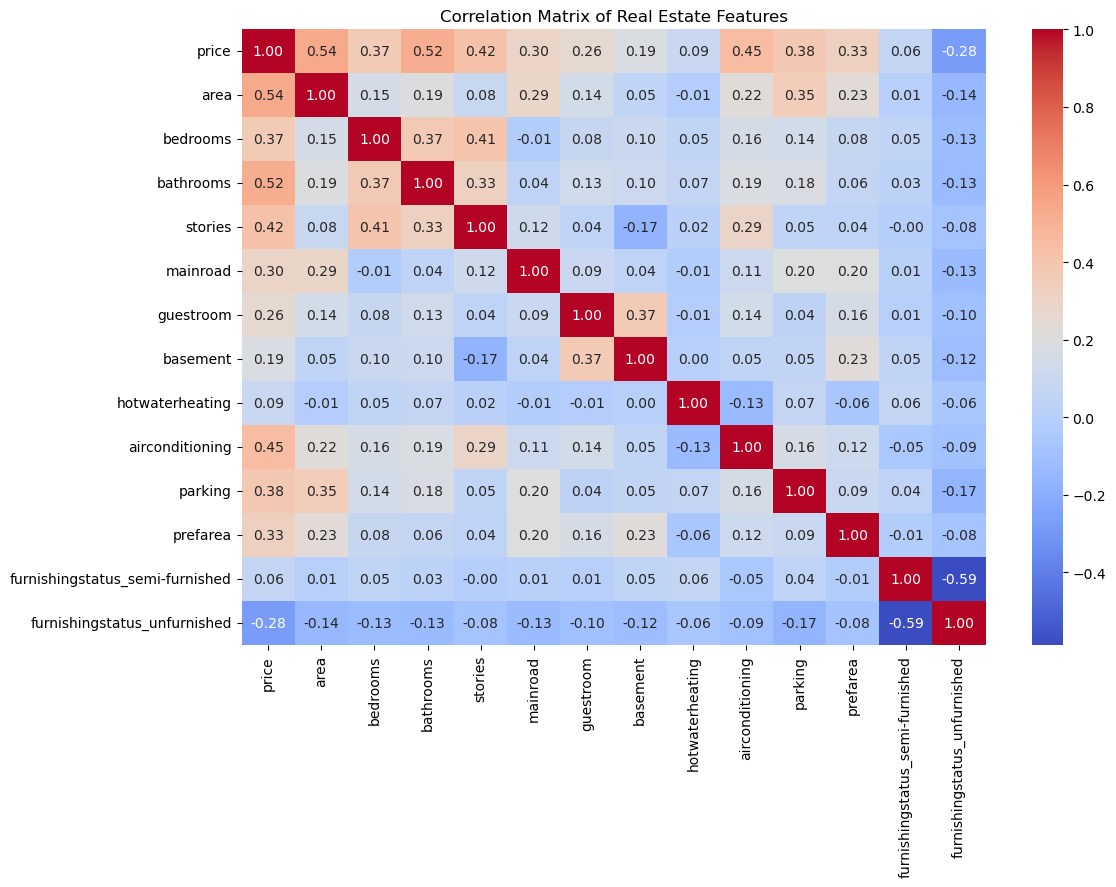

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# حساب مصفوفة الارتباط
correlation_matrix = df.corr()

# رسم الخريطة الحرارية (Heatmap)
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Real Estate Features")
plt.show()